<a href="https://colab.research.google.com/github/omkar834-droidk/loan_approval_predication/blob/main/loan_approva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [187]:
df = pd.read_csv("/content/loan_approval_data.csv")

In [188]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [189]:
df.shape

(1000, 20)

In [190]:
df.isnull().sum()

,0
Applicant_ID,50
Applicant_Income,50
Coapplicant_Income,50
Employment_Status,50
Age,50
Marital_Status,50
Dependents,50
Credit_Score,50
Existing_Loans,50
DTI_Ratio,50


In [191]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns


In [192]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [193]:
df.isnull().sum()

,0
Applicant_ID,0
Applicant_Income,0
Coapplicant_Income,0
Employment_Status,0
Age,0
Marital_Status,0
Dependents,0
Credit_Score,0
Existing_Loans,0
DTI_Ratio,0


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [195]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,282.267965,4933.339492,2868.563488,10.857445,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,23.630794
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,262.750000,6857.000000,2701.250000,31.000000,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,24.000000
50%,501.220000,10852.571579,5082.455789,39.971579,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,48.000000
75%,738.250000,14973.250000,7452.750000,49.000000,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [196]:
df.columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')

In [197]:
df.dtypes

,0
Applicant_ID,float64
Applicant_Income,float64
Coapplicant_Income,float64
Employment_Status,object
Age,float64
Marital_Status,object
Dependents,float64
Credit_Score,float64
Existing_Loans,float64
DTI_Ratio,float64


In [198]:
df.duplicated().sum()

np.int64(0)

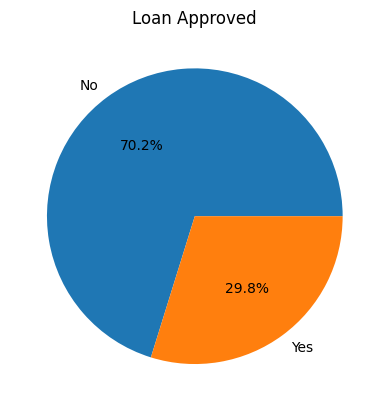

In [199]:
plt.pie(df['Loan_Approved'].value_counts(),labels=df['Loan_Approved'].value_counts().index , autopct="%1.1f%%")
plt.title("Loan Approved")
plt.show()


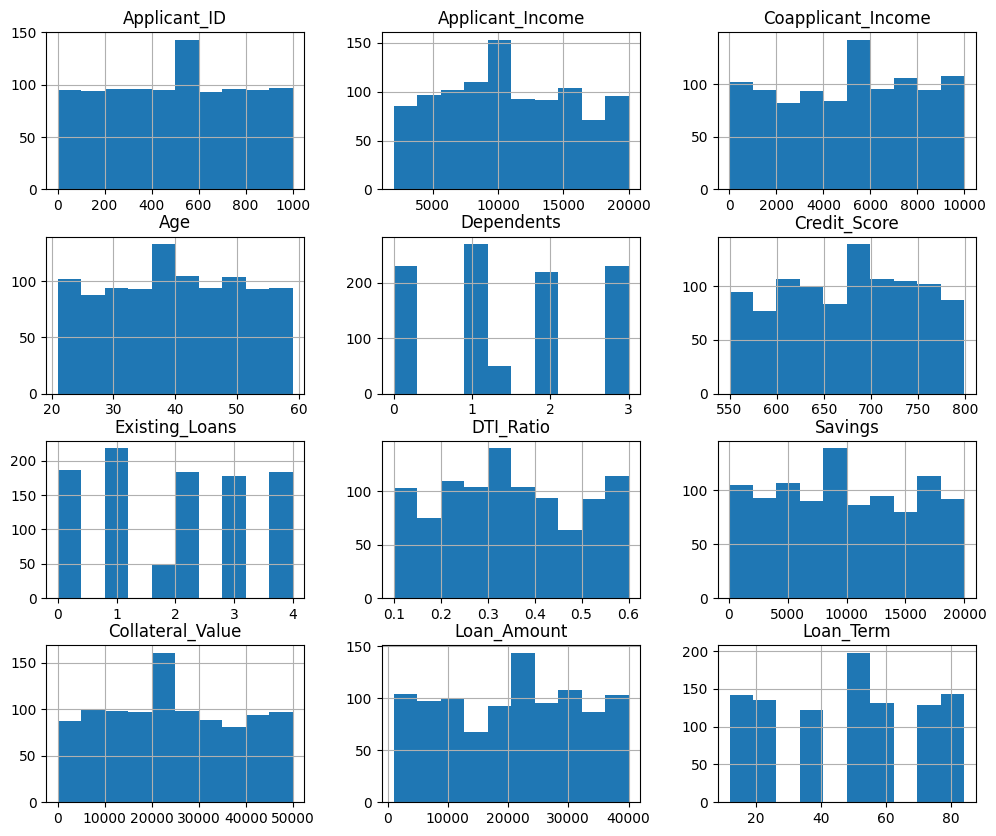

In [200]:
df.hist(figsize=(12,10))
plt.show()

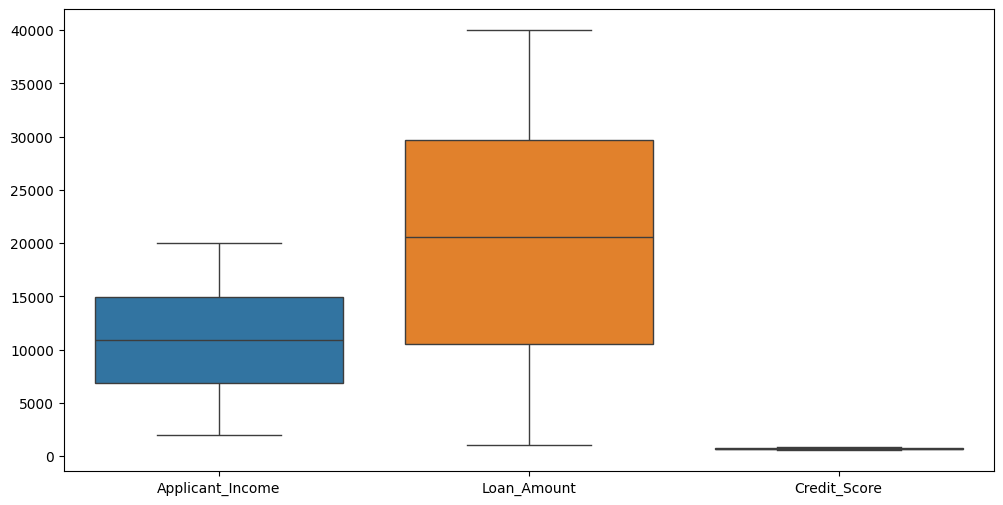

In [201]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Applicant_Income','Loan_Amount','Credit_Score']])
plt.show()

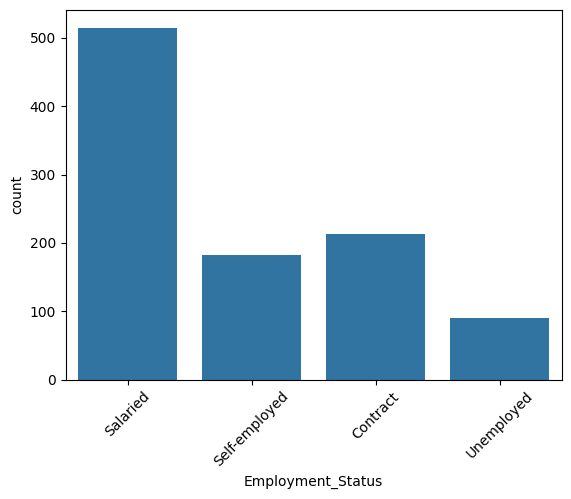

In [202]:
sns.countplot(x='Employment_Status', data=df)
plt.xticks(rotation=45)
plt.show()

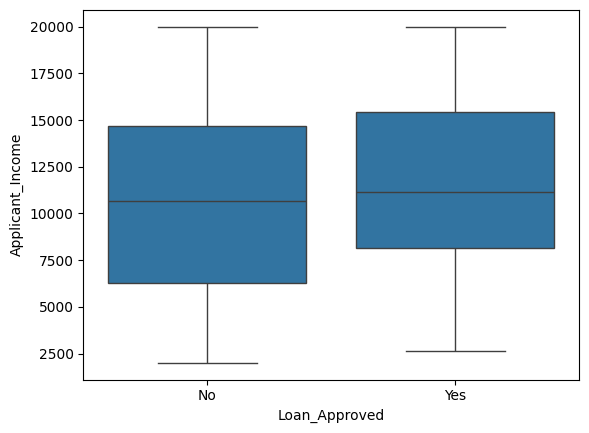

In [203]:
sns.boxplot(x='Loan_Approved', y='Applicant_Income', data=df)
plt.show()

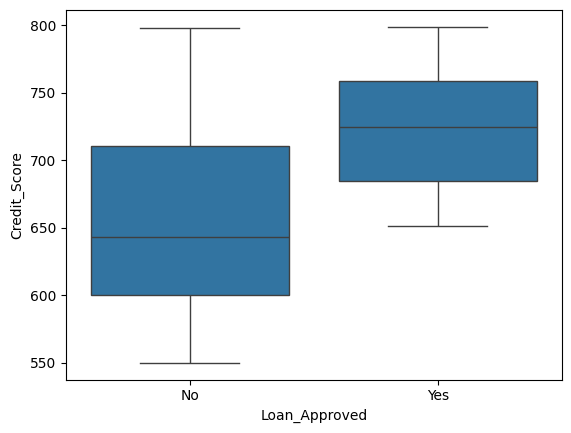

In [204]:
sns.boxplot(x='Loan_Approved', y='Credit_Score', data=df)
plt.show()

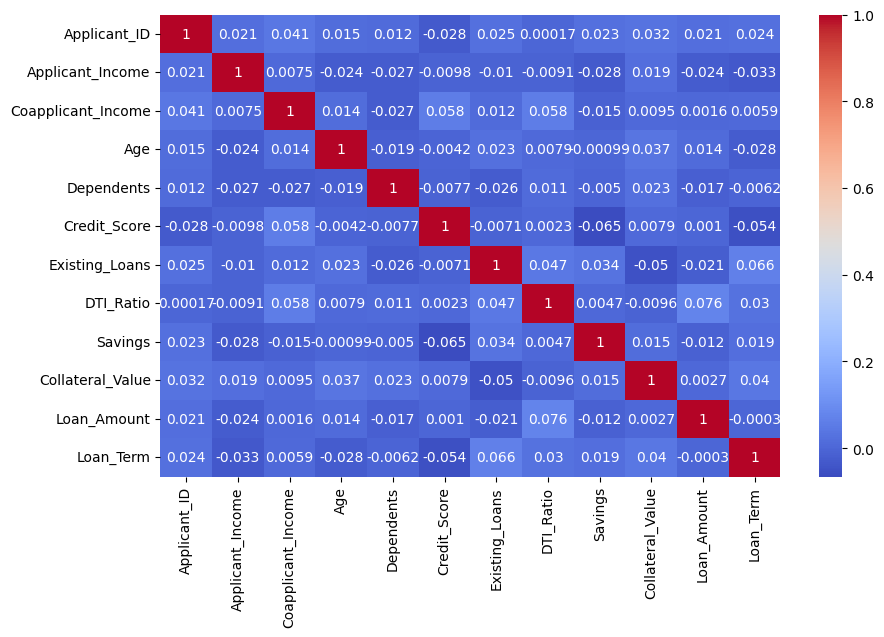

In [205]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [206]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [207]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [208]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [209]:
df.shape

(1000, 29)

<Axes: >

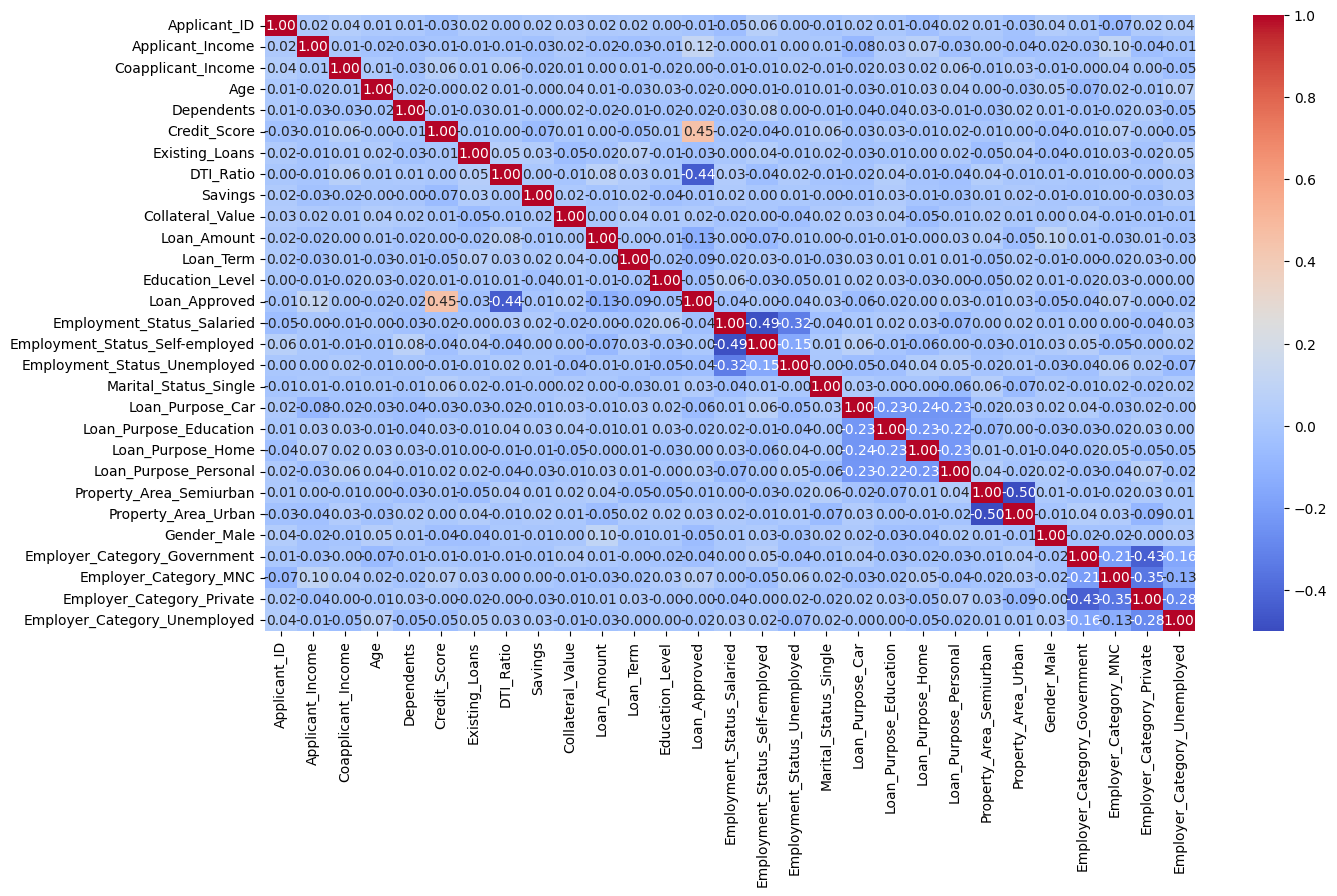

In [210]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [211]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

,Loan_Approved
Loan_Approved,1.000000
Credit_Score,0.451175
Applicant_Income,0.119796
Employer_Category_MNC,0.069049
Loan_Purpose_Personal,0.034043
Marital_Status_Single,0.030182
Property_Area_Urban,0.025963
Collateral_Value,0.021868
Coapplicant_Income,0.004230
Loan_Purpose_Home,0.002118


In [212]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [213]:
from sklearn.model_selection import train_test_split

In [214]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### MODEL ==> **Logistic_Regression**

In [215]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [216]:
from sklearn.linear_model import LogisticRegression


log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

In [217]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score ,classification_report


In [218]:
print("Logistic Regression Model:")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))

print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model:
Precision:  0.7868852459016393
Recall:  0.7868852459016393
F1 Score:  0.7868852459016393
Accuracy:  0.87
CM:  [[126  13]
 [ 13  48]]


MODEL ==> **KNN**

In [219]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

In [220]:
print("KNN Model:")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

KNN Model:
Precision:  0.5957446808510638
Recall:  0.45901639344262296
F1 Score:  0.5185185185185185
Accuracy:  0.74
CM:  [[120  19]
 [ 33  28]]


MODEL ==>  **NAIVE_BAYES**

In [221]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

In [222]:
print("Naive Bayes Model:")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model:
Precision:  0.8035714285714286
Recall:  0.7377049180327869
F1 Score:  0.7692307692307693
Accuracy:  0.865
CM:  [[128  11]
 [ 16  45]]


MODEL ===>  **DECISION TREE**

In [223]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [224]:
print("DecisionTreeClassifier:")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

DecisionTreeClassifier:
Precision:  0.8235294117647058
Recall:  0.9180327868852459
F1 Score:  0.8682170542635659
Accuracy:  0.915
CM:  [[127  12]
 [  5  56]]


In [225]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

MODEL ===> **RANDOM_FOREST**

In [226]:
print("Random_Forest :")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Random_Forest :
Precision:  0.8225806451612904
Recall:  0.8360655737704918
F1 Score:  0.8292682926829268
Accuracy:  0.895
CM:  [[128  11]
 [ 10  51]]


MODEL ===> **XGB**

In [227]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

In [228]:
print(" XGB :")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

 XGB :
Precision:  0.8382352941176471
Recall:  0.9344262295081968
F1 Score:  0.8837209302325582
Accuracy:  0.925
CM:  [[128  11]
 [  4  57]]


In [229]:
def evaluate_model(name, model):

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

In [230]:
results = []
evaluate_model("Logistic Regression", log_model)
evaluate_model("KNN", knn_model)
evaluate_model("Naive Bayes", nb_model)
evaluate_model("Decision Tree", model)
evaluate_model("Random Forest", rf)
evaluate_model("XGBoost", xgb)

In [234]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision    Recall  F1 Score  Accuracy
0  Logistic Regression   0.375887  0.868852  0.524752     0.520
1                  KNN   0.380952  0.262295  0.310680     0.645
2          Naive Bayes   0.333333  0.016393  0.031250     0.690
3        Decision Tree   0.823529  0.918033  0.868217     0.915
4        Random Forest   0.822581  0.836066  0.829268     0.895
5              XGBoost   0.838235  0.934426  0.883721     0.925


In [235]:
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Precision,Recall,F1 Score,Accuracy
5,XGBoost,0.838235,0.934426,0.883721,0.925
3,Decision Tree,0.823529,0.918033,0.868217,0.915
4,Random Forest,0.822581,0.836066,0.829268,0.895
0,Logistic Regression,0.375887,0.868852,0.524752,0.520
1,KNN,0.380952,0.262295,0.310680,0.645
2,Naive Bayes,0.333333,0.016393,0.031250,0.690


### Model Selection

In this project, multiple classification models were trained for the **Loan Approval Prediction** task, including **Logistic Regression**, **KNN**, **Naive Bayes**, **Decision Tree**, **Random Forest**, and **XGBoost**.

The models were evaluated using important performance metrics such as **Precision**, **Recall**, **F1 Score**, and **Accuracy**.

After comparing all models, **XGBoost** and **Decision Tree** achieved the **highest F1 Score and Accuracy**, indicating better performance in predicting loan approvals.

Since **F1 Score provides a balanced measure of Precision and Recall**, it was used as the primary metric for model comparison.

Therefore, **XGBoost and Decision Tree were selected as the top-performing models** for the final loan approval prediction system.


In [ ]:
top2_models = results_df.sort_values(by="F1 Score", ascending=False).head(2)

print(top2_models)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF Score:", rf_grid.best_score_)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric="logloss")

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB Score:", xgb_grid.best_score_)

In [ ]:

best_xgb = xgb_grid.best_estimator_

In [ ]:
from sklearn.metrics import classification_report

y_pred = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
importances = best_xgb.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

print(feat_imp)

In [ ]:
plt.figure(figsize=(10,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = best_xgb.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=results_df)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=45)

plt.show()

In [ ]:
results_df.set_index("Model")[["Precision","Recall","F1 Score","Accuracy"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

### 📌 Conclusion

In this project, a machine learning–based **💳 Loan Approval Prediction System** was developed to determine whether a loan application should be **approved ✅ or rejected ❌**. The dataset was first preprocessed through **data cleaning, feature preparation, and categorical encoding**, ensuring that the data was suitable for machine learning models.

Several classification algorithms were trained and evaluated, including **Logistic Regression, KNN, Naive Bayes, Decision Tree 🌳, Random Forest 🌲, and XGBoost 🚀**. The models were compared using important performance metrics such as **Precision, Recall, F1 Score, and Accuracy 📊**.

Based on the evaluation results, **XGBoost 🚀 and Decision Tree 🌳** achieved the **best performance**, particularly in terms of **F1 Score and overall accuracy**. To further improve the models, **hyperparameter tuning ⚙️** was applied, which helped optimize their predictive capability.

Overall, the final model demonstrates **strong performance and reliability ⭐**, making it suitable for predicting loan approvals. Such a system can help financial institutions make **data-driven decisions 📈**, reduce manual evaluation time ⏱️, and improve the efficiency of the loan approval process.


In [ ]:
import joblib

joblib.dump(best_xgb, "loan_approval_model.pkl")

In [ ]:
model = joblib.load("loan_approval_model.pkl")

In [ ]:
def predict_loan(data):

    pred = model.predict(data)

    if pred == 1:
        return "Loan Approved ✅"
    else:
        return "Loan Rejected ❌"

In [ ]:
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_

plt.barh(X.columns, importances)

plt.title("Feature Importance")

plt.show()